In [40]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import tensorflow as tf

from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input,Dense,BatchNormalization,Dropout,LeakyReLU)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import (EarlyStopping,ReduceLROnPlateau)

np.random.seed(42)
tf.random.set_seed(42)

In [41]:
# DATASET PATH

file_path = '/mnt/DATA/SPLAB/EE25M314/MLWC_project/SNR-CRB-constrained-beamforming-for-RIS-ISAC-main/code/RIS_ISAC_DATASET_CLEAN_NORMALIZED_02.mat'
mat = h5py.File(file_path, 'r')
print('AVAILABLE VARIABLES:-')
print(list(mat.keys()))

AVAILABLE VARIABLES:-
['#refs#', 'X_mean', 'X_norm', 'X_std', 'Y_mean', 'Y_norm', 'Y_std', 'feature_names', 'label_names']


In [42]:
# LOAD DATA

X_norm = np.array(mat['X_norm']).T
Y_norm = np.array(mat['Y_norm']).T

print('DATASET:')

print('X shape :', X_norm.shape)
print('Y shape :', Y_norm.shape)

Y_mean = np.squeeze(np.array(mat['Y_mean']))
Y_std = np.squeeze(np.array(mat['Y_std']))

target_dim = min(Y_norm.shape[1],len(Y_mean),len(Y_std))
Y_norm = Y_norm[:, :target_dim]
Y_mean = Y_mean[:target_dim]
Y_std  = Y_std[:target_dim]

print('\nCorrected output dimension :', target_dim)

DATASET:
X shape : (3000, 1139)
Y shape : (3000, 219)

Corrected output dimension : 218


In [43]:
M = 6
K = 4
N = 49
P_dbm_range = np.array([27,28,29,30,31,32])
P_linear = 10 ** ((P_dbm_range - 30)/10)

In [44]:
power_feature = np.random.choice(P_dbm_range,size=(X_norm.shape[0],1))

# NORMALIZE POWER FEATURE

power_feature = (power_feature - np.mean(power_feature)) / np.std(power_feature)

# APPEND TO INPUT

X_norm = np.concatenate([X_norm, power_feature],axis=1)

print('\nPower-aware input shape :', X_norm.shape)


Power-aware input shape : (3000, 1140)


In [45]:
# TRAIN TEST SPLIT

X_train, X_test, Y_train, Y_test = train_test_split(X_norm,Y_norm,test_size=0.2,random_state=42,shuffle=True)

print('\nTrain shape :', X_train.shape)
print('Test shape  :', X_test.shape)


Train shape : (2400, 1140)
Test shape  : (600, 1140)


In [46]:
# MODEL

def build_model(input_dim, output_dim):

    inp = Input(shape=(input_dim,))

    # BLOCK 1

    x = Dense(2048,kernel_regularizer=l2(1e-5))(inp)
    x = BatchNormalization()(x)
    x = LeakyReLU(0.1)(x)
    x = Dropout(0.2)(x)

    # BLOCK 2

    x = Dense(1024,kernel_regularizer=l2(1e-5))(x)
    x = BatchNormalization()(x)
    x = LeakyReLU(0.1)(x)
    x = Dropout(0.2)(x)

    # BLOCK 3

    x = Dense(512,kernel_regularizer=l2(1e-5))(x)
    x = BatchNormalization()(x)
    x = LeakyReLU(0.1)(x)

    # BLOCK 4
    
    x = Dense(256,kernel_regularizer=l2(1e-5))(x)
    x = BatchNormalization()(x)
    x = LeakyReLU(0.1)(x)

    # OUTPUT

    out = Dense(output_dim,activation='linear')(x)
    model = Model(inp, out)
    model.compile( optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),loss='mse',metrics=['mae'])
    return model

model = build_model(X_train.shape[1],Y_train.shape[1])
model.summary()

callbacks = [EarlyStopping(monitor='val_loss',patience=20,restore_best_weights=True),ReduceLROnPlateau(monitor='val_loss',factor=0.5,patience=8,min_lr=1e-6)]

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 1140)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 2048)           │     2,336,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_8 (LeakyReLU)       │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_9 (LeakyReLU)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_10 (LeakyReLU)      │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_11 (LeakyReLU)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 218)            │        56,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,162,458 (19.69 MB)

 Trainable params: 5,154,778 (19.66 MB)

 Non-trainable params: 7,680 (30.00 KB)

In [47]:
history = model.fit(X_train,Y_train,validation_data=(X_test, Y_test),epochs=50,batch_size=64,callbacks=callbacks,verbose=1)

Epoch 1/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 1.1577 - mae: 0.8144 - val_loss: 0.7897 - val_mae: 0.6184 - learning_rate: 1.0000e-04
Epoch 2/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.9936 - mae: 0.7452 - val_loss: 0.8038 - val_mae: 0.6272 - learning_rate: 1.0000e-04
Epoch 3/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.8866 - mae: 0.6930 - val_loss: 0.8188 - val_mae: 0.6356 - learning_rate: 1.0000e-04
Epoch 4/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.8069 - mae: 0.6471 - val_loss: 0.8110 - val_mae: 0.6302 - learning_rate: 1.0000e-04
Epoch 5/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.7563 - mae: 0.6142 - val_loss: 0.7912 - val_mae: 0.6153 - learning_rate: 1.0000e-04
Epoch 6/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.7287 - mae: 0.5923 - val_loss: 0.7741 - val_mae: 0.6014 - learning_rate: 1.0000e-04
Epoch 7/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.7131 - mae: 0.5775 - val_loss: 0.7608 - val_mae: 0.5889 - learning_ra

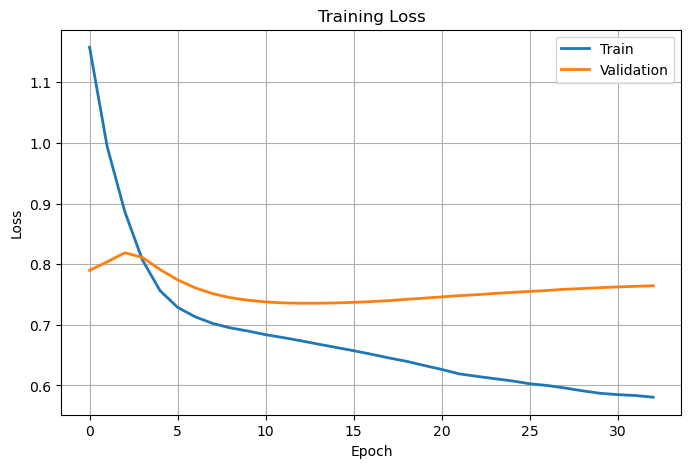

In [48]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'],linewidth=2,label='Train')
plt.plot(history.history['val_loss'],linewidth=2,label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.grid(True)
plt.legend()
plt.show()

In [49]:
Y_pred_norm = model.predict(X_test)
Y_pred = Y_pred_norm * Y_std + Y_mean
print('\nPrediction shape :', Y_pred.shape)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

Prediction shape : (600, 218)


In [50]:
# OUTPUT STRUCTURE

num_w_real = M * (K + M)
num_w_imag = M * (K + M)

num_phi_real = N
num_phi_imag = N

idx1 = num_w_real
idx2 = idx1 + num_w_imag

idx3 = idx2 + num_phi_real
idx4 = idx3 + num_phi_imag

if idx4 > Y_pred.shape[1]:raise ValueError('\nDataset output structure inconsistent.')

In [51]:
phi_real = Y_pred[:, idx2:idx3]
phi_imag = Y_pred[:, idx3:idx4]
phi = phi_real + 1j * phi_imag

# UNIT MODULUS CONSTRAINT

phi = phi / (np.abs(phi) + 1e-12)
print('\nPhi shape :', phi.shape)


Phi shape : (600, 49)


In [52]:
# PHYSICS CHANNELS

num_samples = X_test.shape[0]
Hd = (np.random.randn(num_samples, K, M) + 1j*np.random.randn(num_samples, K, M)) # DIRECT CHANNEL
G = (np.random.randn(num_samples, N, M) + 1j*np.random.randn(num_samples, N, M)) # BS-RIS CHANNEL
Hr = (np.random.randn(num_samples, K, N) + 1j*np.random.randn(num_samples, K, N)) # RIS-USER CHANNEL

# EFFECTIVE CHANNEL

def effective_channel(Hd,G,Hr,phi):
    H_eff = np.zeros_like(Hd)
    Phi = np.diag(phi)

    for k in range(K):
        reflected = (Hr[k] @ Phi @ G)
        H_eff[k] = (Hd[k] + reflected)
    return H_eff


In [53]:
# ZERO FORCING BEAMFORMING

def zf_beamforming(H_eff,Pt):

    """
    H_eff : (K,M)

    returns:
    W : (M,K)
    """
    H = H_eff

    W = (H.conj().T @ np.linalg.pinv(H @ H.conj().T)) # ZERO FORCING PRECODER

    # POWER NORMALIZATION

    power = np.linalg.norm(W,'fro')**2
    if power > 0:
        W = W * np.sqrt(Pt / power)
    return W

    # SUM RATE FUNCTION

def compute_sum_rate(H_eff,W,noise_power=1):
    sum_rate = 0
    for k in range(K):
        hk = H_eff[k]
        signal = np.abs(hk @ W[:,k])**2 # SIGNAL
        interference = 0
        for j in range(K):
            if j != k:
                interference += np.abs(hk @ W[:,j])**2
        sinr = signal / (interference + noise_power)
        sum_rate += np.log2(1 + sinr)
    return np.real(sum_rate)

# EVALUATE SUM RATE

SR_my = []
print('SUM RATE EVALUATION:')

for p_idx, Pt in enumerate(P_linear):
    sr_temp = []
    for i in range(min(100, num_samples)):
        for i in range(min(100, num_samples)):
            H_eff = effective_channel( Hd[i],G[i],Hr[i],phi[i])
            W_temp = zf_beamforming(H_eff,Pt)
            sr = compute_sum_rate(H_eff,W_temp,noise_power=1)
            sr_temp.append(sr)
    avg_sr = np.mean(sr_temp)
    SR_my.append(avg_sr)
    print(f'Power {P_dbm_range[p_idx]} dBm : 'f'{avg_sr:.4f}')
SR_my = np.array(SR_my)


SUM RATE EVALUATION:
Power 27 dBm : 22.8098
Power 28 dBm : 24.1128
Power 29 dBm : 25.4211
Power 30 dBm : 26.7334
Power 31 dBm : 28.0491
Power 32 dBm : 29.3675


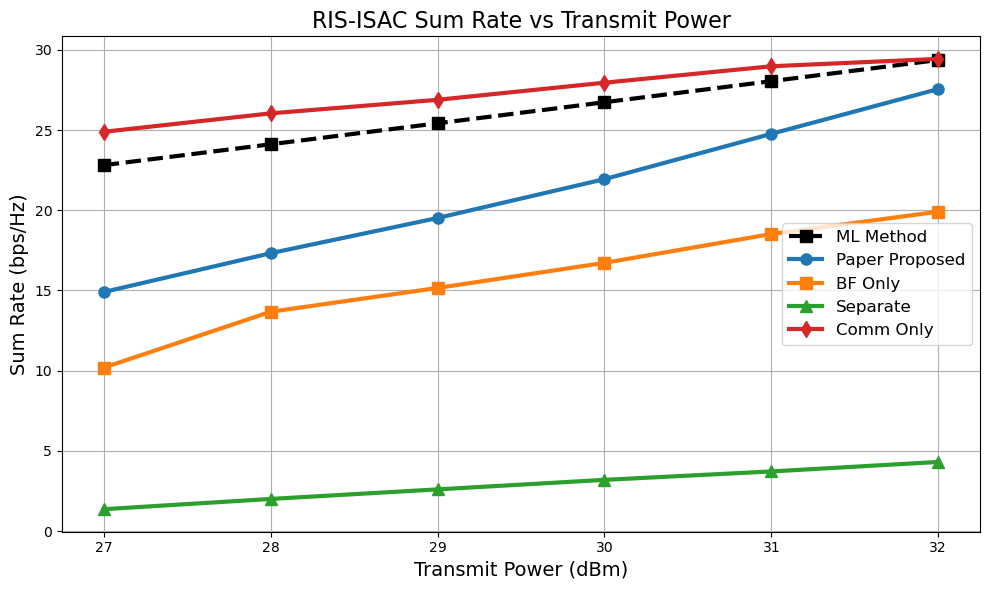

In [54]:
from scipy.io import loadmat

paper_data = loadmat('/mnt/DATA/SPLAB/EE25M314/MLWC_project/SNR-CRB-constrained-beamforming-for-RIS-ISAC-main/code/sumrate_vs_power_results_01.mat')

P_dbm_range_paper = paper_data['P_dbm_range'].squeeze()
SR_paper_proposed = paper_data['SR_my'].squeeze()
SR_max_CG_RIS = paper_data['SR_max_CG_RIS'].squeeze()
SR_sep = paper_data['SR_sep'].squeeze()
SR_comm_only = paper_data['SR_comm_only'].squeeze()


plt.figure(figsize=(10,6))

plt.plot(P_dbm_range,SR_my,'ks--',linewidth=3,markersize=8,label='ML Method')
plt.plot(P_dbm_range_paper,SR_paper_proposed,'o-',linewidth=3,markersize=8,label='Paper Proposed')
plt.plot(P_dbm_range_paper,SR_max_CG_RIS,'s-',linewidth=3,markersize=8,label='BF Only')
plt.plot(P_dbm_range_paper,SR_sep,'^-',linewidth=3,markersize=8,label='Separate')
plt.plot(P_dbm_range_paper,SR_comm_only, 'd-',linewidth=3,markersize=8,label='Comm Only')

plt.xlabel('Transmit Power (dBm)',fontsize=14)
plt.ylabel('Sum Rate (bps/Hz)',fontsize=14)
plt.title('RIS-ISAC Sum Rate vs Transmit Power',fontsize=16)
plt.grid(True)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

model.save('RIS_ISAC_FINAL_MODEL.h5')
